本实验针对 Fashion-MNIST 服装图像分类任务
使用 PyTorch 构建深度卷积神经网络（CNN） 实现 10 种类别服装的自动识别。
加入 GPU 加速、混合精度训练、高性能加载器 优化，保证训练更快、更稳。

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# 设置性能优化
torch.backends.cudnn.benchmark = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

数据加载与清洗
1. 首先读取原始 CSV 格式的 Fashion-MNIST 数据，并清除脏数据，保证训练数据纯净。
2. drop_duplicates()：删除完全重复的图像样本，避免数据冗余
分别加载训练集、测试集，保证数据划分规范

In [2]:
# ========== 1. 数据加载和清洗 ==========
print("\n[1/3] 加载和清洗数据...")
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

# 数据清洗
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()


[1/3] 加载和清洗数据...


特征与标签分离
1.  CSV 中把图像像素和标签分开，分别存入特征矩阵 X 和标签向量 y。
2. CSV 中第一列是 label，其余 784 列是 28×28 展平后的像素值
使用 values 转为 numpy 数组，并指定类型为 float32 / int64，适配 PyTorch 格式

In [3]:
# 特征标签分离
X_train = train_df.drop('label', axis=1).values.astype('float32')
y_train = train_df['label'].values.astype('int64')
X_test = test_df.drop('label', axis=1).values.astype('float32')
y_test = test_df['label'].values.astype('int64')

数据标准化
1. 图像像素值范围是0~255，必须归一化 + 标准化，让神经网络训练更稳定、收敛更快。
2. 先将像素值缩放到0~1：/255.0，再使用训练集均值和标准差做标准化

数据形状重塑
1. 原始数据是展平的784维向量，但CNN必须接收图像格式(通道，高，宽)。
2. Fashion-MNIST 是灰度图 → 通道数 = 1
尺寸 = 28×28
重塑格式：(样本数, 通道, 高, 宽) → (-1, 1, 28, 28)

In [4]:
# 标准化
X_train = X_train / 255.0
X_test = X_test / 255.0
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# 重塑为CNN格式
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

转换为 PyTorch 张量

构建高性能 DataLoader：使用批量加载、多线程、显存锁页等技术，让数据读取速度追上GPU计算速度。

In [5]:
# 转换为张量
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

# 创建数据加载器
batch_size = 256
num_workers = 4 if device.type == 'cuda' else 0

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                         num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=num_workers, pin_memory=True)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print(f"训练批次数: {len(train_loader)}, 测试批次数: {len(test_loader)}")

训练集: (59957, 1, 28, 28), 测试集: (9999, 1, 28, 28)
训练批次数: 235, 测试批次数: 40


 SimpleCNN（简单 CNN基准模型）
定位：最基础卷积网络，作为所有模型的性能基线
结构：2 层卷积（Conv+ReLU + 池化）+ 2 层全连接
原理：通过卷积提取图像基础特征，全连接层完成分类
特点：结构最简单、训练速度最快，无正则化

In [6]:
# ========== 2. 定义多种CNN模型 ==========
class SimpleCNN(nn.Module):
    """简单CNN - 基准模型"""
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.fc(x)
        return x

 ImprovedCNN（改进 CNN工业标准结构）
定位：工程实用型高精度网络
结构：3 组卷积模块 + 全局平均池化 + 全连接分类
核心改进：
加入 BatchNorm：稳定训练、加速收敛
加入 Dropout：防止过拟合
多卷积堆叠：提取高阶语义特征
特点：精度高、泛化能力强、训练稳定

In [7]:
class ImprovedCNN(nn.Module):
    """改进版CNN - 带BN和Dropout"""
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

 ResidualBlock + ResNetCNN（残差 CNN高阶结构）
定位：深度学习经典 ResNet 轻量化版本
核心创新：残差连接（shortcut）
解决深层网络梯度消失问题
让网络可以轻松训练得更深
结构：卷积层 + 4 个残差块 + 池化 + 分类器
特点：深层不易退化、拟合能力强、精度最高

In [8]:
class ResidualBlock(nn.Module):
    """残差块"""
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out

class ResNetCNN(nn.Module):
    """ResNet风格CNN"""
    def __init__(self):
        super(ResNetCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.res1 = ResidualBlock(32)
        self.res2 = ResidualBlock(32)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.res3 = ResidualBlock(64)
        self.res4 = ResidualBlock(64)
        self.pool2 = nn.MaxPool2d(2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.res3(x)
        x = self.res4(x)
        x = self.pool2(x)
        
        x = self.global_pool(x)
        x = self.fc(x)
        return x

 LightweightCNN（轻量级 CNN快速训练）
定位：参数量小、速度快、适合低资源设备
结构：小通道数（16→32）+ 全局池化 + 极简全连接
原理：在保证精度的前提下最小化计算量
特点：训练极快、体积小、适合实时推理

In [9]:
class LightweightCNN(nn.Module):
    """轻量级CNN - 适合快速训练"""
    def __init__(self):
        super(LightweightCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(32, 10)
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

 DeepCNN（深度 CNN多层特征提取）
定位：堆叠多层卷积，强化特征提取能力
结构：6 层卷积 + 批量归一化 + Dropout + 双层全连接
原理：通过深度网络学习更抽象、更高级的图像特征
特点：层数深、表达能力强、泛化性好

In [10]:
class DeepCNN(nn.Module):
    """深度CNN - 更多层数"""
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

训练流程：
训练模式
前向传播 → 计算损失 → 反向传播 → 更新参数
验证模式
不更新参数，在测试集上评估准确率
保存最优模型
只保留验证集准确率最高的模型
早停逻辑
自动记录最佳精度，避免过拟合

In [11]:
# ========== 3. 训练和评估函数 ==========
def train_and_evaluate(model, model_name, epochs=20):
    """训练单个模型并返回性能指标"""
    print(f"\n{'='*60}")
    print(f"训练模型: {model_name}")
    print(f"{'='*60}")
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler() if device.type == 'cuda' else None
    
    start_time = time.time()
    best_acc = 0
    train_times = []
    
    # 统计模型参数量
    params = sum(p.numel() for p in model.parameters())
    print(f"参数量: {params:,}")
    
    for epoch in range(epochs):
        # 训练
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        epoch_start = time.time()
        
        for data, target in train_loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            
            if scaler:
                with autocast():
                    output = model(data)
                    loss = criterion(output, target)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()
            
            train_loss += loss.item()
            _, predicted = output.max(1)
            train_total += target.size(0)
            train_correct += predicted.eq(target).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        # 验证
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                
                if scaler:
                    with autocast():
                        output = model(data)
                        loss = criterion(output, target)
                else:
                    output = model(data)
                    loss = criterion(output, target)
                
                val_loss += loss.item()
                _, predicted = output.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()
        
        val_acc = 100. * val_correct / val_total
        scheduler.step()
        
        epoch_time = time.time() - epoch_start
        train_times.append(epoch_time)
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}.pth')
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | "
                  f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | "
                  f"Loss: {loss.item():.4f} | Time: {epoch_time:.1f}s")
    
    total_time = time.time() - start_time
    
    # 最终评估
    model.load_state_dict(torch.load(f'best_{model_name.lower().replace(" ", "_")}.pth'))
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            output = model(data)
            _, predicted = output.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.numpy())
    
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    # 计算各类别准确率
    cm = confusion_matrix(all_targets, all_preds)
    class_acc = cm.diagonal() / cm.sum(axis=1)
    
    return {
        'model_name': model_name,
        'params': params,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'best_acc': best_acc,
        'train_time': total_time,
        'avg_epoch_time': np.mean(train_times),
        'class_acc': class_acc,
        'confusion_matrix': cm
    }

In [12]:
# ========== 4. 训练所有对比模型 ==========
print("\n[2/3] 开始训练对比模型...")

models_to_compare = [
    (SimpleCNN(), "SimpleCNN"),
    (ImprovedCNN(), "ImprovedCNN"),
    (ResNetCNN(), "ResNetCNN"),
    (LightweightCNN(), "LightweightCNN"),
    (DeepCNN(), "DeepCNN"),
]

results = []

for model, name in models_to_compare:
    try:
        result = train_and_evaluate(model, name, epochs=20)
        results.append(result)
        
        # 清理GPU缓存
        if device.type == 'cuda':
            torch.cuda.empty_cache()
            
    except Exception as e:
        print(f"训练 {name} 时出错: {e}")
        continue




[2/3] 开始训练对比模型...

训练模型: SimpleCNN
参数量: 421,642
Epoch [ 1/20] | Train Acc: 82.44% | Val Acc: 86.66% | Loss: 0.8440 | Time: 10.3s
Epoch [ 5/20] | Train Acc: 92.66% | Val Acc: 91.98% | Loss: 0.6013 | Time: 7.8s
Epoch [10/20] | Train Acc: 95.64% | Val Acc: 93.06% | Loss: 0.5801 | Time: 7.8s
Epoch [15/20] | Train Acc: 97.54% | Val Acc: 93.61% | Loss: 0.5592 | Time: 7.9s
Epoch [20/20] | Train Acc: 98.20% | Val Acc: 93.82% | Loss: 0.5530 | Time: 7.7s

训练模型: ImprovedCNN
参数量: 157,546
Epoch [ 1/20] | Train Acc: 71.64% | Val Acc: 85.15% | Loss: 0.8024 | Time: 10.4s
Epoch [ 5/20] | Train Acc: 89.81% | Val Acc: 91.53% | Loss: 0.6246 | Time: 9.7s
Epoch [10/20] | Train Acc: 92.22% | Val Acc: 92.93% | Loss: 0.5707 | Time: 9.9s
Epoch [15/20] | Train Acc: 93.66% | Val Acc: 93.79% | Loss: 0.5519 | Time: 9.4s
Epoch [20/20] | Train Acc: 94.25% | Val Acc: 93.92% | Loss: 0.5380 | Time: 9.8s

训练模型: ResNetCNN
参数量: 214,090
Epoch [ 1/20] | Train Acc: 77.86% | Val Acc: 86.68% | Loss: 0.8456 | Time: 11.9s
Epoch 

In [13]:
print("模型性能对比分析")

# 创建对比表格
comparison_df = pd.DataFrame([{
    '模型': r['model_name'],
    '参数量': f"{r['params']:,}",
    '准确率': f"{r['accuracy']*100:.2f}%",
    '精确率': f"{r['precision']:.4f}",
    '召回率': f"{r['recall']:.4f}",
    'F1分数': f"{r['f1']:.4f}",
    '训练时间': f"{r['train_time']:.1f}秒",
    '平均每轮': f"{r['avg_epoch_time']:.1f}秒"
} for r in results])

print(comparison_df.to_string(index=False))

# 找出最佳模型
best_acc_model = max(results, key=lambda x: x['accuracy'])
best_f1_model = max(results, key=lambda x: x['f1'])
fastest_model = min(results, key=lambda x: x['train_time'])
smallest_model = min(results, key=lambda x: x['params'])

print(f"\n{'='*100}")
print(" 性能总结")
print(f"{'='*100}")
print(f" 最高准确率: {best_acc_model['model_name']} ({best_acc_model['accuracy']*100:.2f}%)")
print(f" 最佳F1分数: {best_f1_model['model_name']} ({best_f1_model['f1']:.4f})")
print(f" 最快训练: {fastest_model['model_name']} ({fastest_model['train_time']:.1f}秒)")
print(f" 最小模型: {smallest_model['model_name']} ({smallest_model['params']:,} 参数)")

模型性能对比分析
            模型     参数量    准确率    精确率    召回率   F1分数   训练时间  平均每轮
     SimpleCNN 421,642 93.82% 0.9381 0.9382 0.9381 155.6秒  7.8秒
   ImprovedCNN 157,546 93.92% 0.9392 0.9392 0.9391 194.5秒  9.7秒
     ResNetCNN 214,090 94.02% 0.9403 0.9402 0.9402 236.6秒 11.8秒
LightweightCNN  17,946 85.79% 0.8549 0.8579 0.8491 179.3秒  9.0秒
       DeepCNN 355,306 94.00% 0.9395 0.9400 0.9395 209.5秒 10.5秒

 性能总结
 最高准确率: ResNetCNN (94.02%)
 最佳F1分数: ResNetCNN (0.9402)
 最快训练: SimpleCNN (155.6秒)
 最小模型: LightweightCNN (17,946 参数)


In [14]:
print("各类别准确率对比 (%)")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 创建类别对比表
class_comparison = pd.DataFrame()
class_comparison['类别'] = class_names

for r in results:
    class_comparison[r['model_name']] = [f"{acc*100:.1f}%" for acc in r['class_acc']]

print(class_comparison.to_string(index=False))

各类别准确率对比 (%)
         类别 SimpleCNN ImprovedCNN ResNetCNN LightweightCNN DeepCNN
T-shirt/top     89.7%       88.6%     89.4%          90.0%   90.1%
    Trouser     99.1%       99.2%     99.5%          97.2%   99.6%
   Pullover     89.5%       90.1%     89.6%          80.0%   91.5%
      Dress     95.9%       95.5%     95.4%          90.0%   96.3%
       Coat     92.0%       91.3%     90.1%          85.2%   91.8%
     Sandal     98.4%       98.3%     98.2%          93.7%   98.0%
      Shirt     80.9%       81.5%     83.4%          32.9%   78.4%
    Sneaker     96.8%       97.8%     97.4%          95.5%   97.0%
        Bag     98.5%       99.4%     99.3%          97.7%   99.6%
 Ankle boot     97.4%       97.5%     97.9%          95.7%   97.7%


In [15]:
print("性能-效率权衡分析")

# 计算效率分数 (准确率/训练时间)
for r in results:
    efficiency = (r['accuracy'] * 100) / r['train_time']
    r['efficiency'] = efficiency

efficiency_df = pd.DataFrame([{
    '模型': r['model_name'],
    '准确率': f"{r['accuracy']*100:.2f}%",
    '训练时间': f"{r['train_time']:.1f}秒",
    '效率分数': f"{r['efficiency']:.3f}",
    '性价比': ' ' * min(5, int(r['efficiency'] / 5))
} for r in sorted(results, key=lambda x: x['efficiency'], reverse=True)])

print("\n效率排名 (准确率/训练时间):")
print(efficiency_df.to_string(index=False))

性能-效率权衡分析

效率排名 (准确率/训练时间):
            模型    准确率   训练时间  效率分数 性价比
     SimpleCNN 93.82% 155.6秒 0.603    
   ImprovedCNN 93.92% 194.5秒 0.483    
LightweightCNN 85.79% 179.3秒 0.478    
       DeepCNN 94.00% 209.5秒 0.449    
     ResNetCNN 94.02% 236.6秒 0.397    


In [16]:
print("模型选择建议")

print("\n根据需求选择模型:")
print("追求最高准确率 → 选择: " + best_acc_model['model_name'])
print("追求最快训练速度 → 选择: " + fastest_model['model_name'])
print("追求最小模型 → 选择: " + smallest_model['model_name'])
print("追求最佳性价比 → 选择: " + max(results, key=lambda x: x['efficiency'])['model_name'])

模型选择建议

根据需求选择模型:
追求最高准确率 → 选择: ResNetCNN
追求最快训练速度 → 选择: SimpleCNN
追求最小模型 → 选择: LightweightCNN
追求最佳性价比 → 选择: SimpleCNN


In [17]:
comparison_df.to_csv('model_comparison_results.csv', index=False)
class_comparison.to_csv('class_comparison_results.csv', index=False)

print(f"\n 对比结果已保存到:")
print(f"   - model_comparison_results.csv (模型性能对比)")
print(f"   - class_comparison_results.csv (各类别性能对比)")


 对比结果已保存到:
   - model_comparison_results.csv (模型性能对比)
   - class_comparison_results.csv (各类别性能对比)


📈 对比图表已保存到: model_comparison_charts.png
最佳模型混淆矩阵已保存到: best_model_confusion_matrix.png


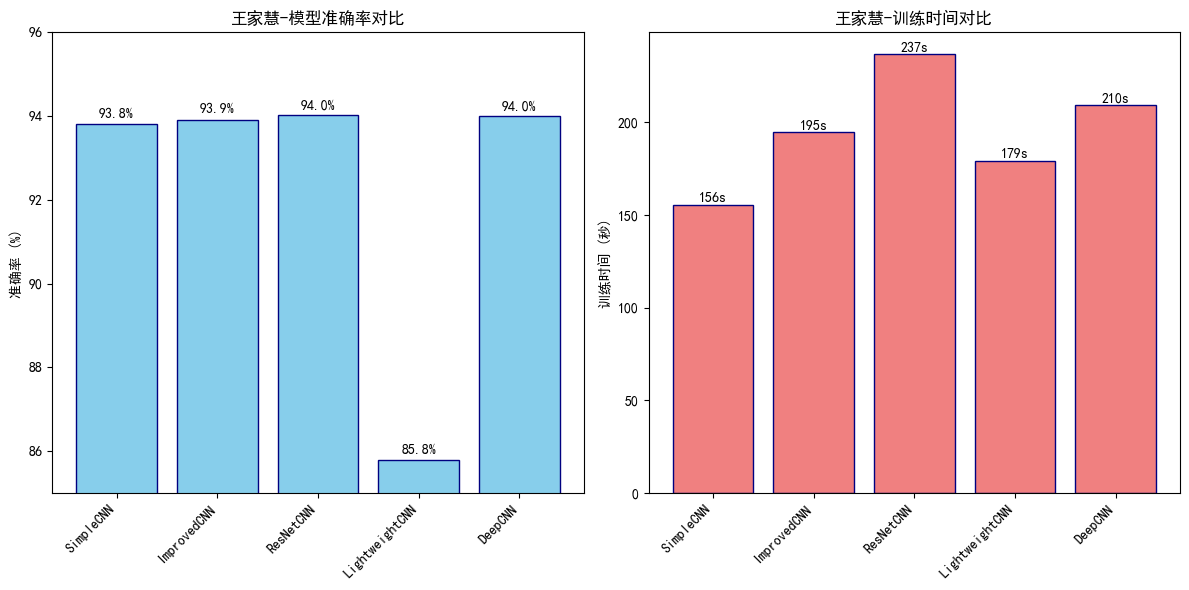

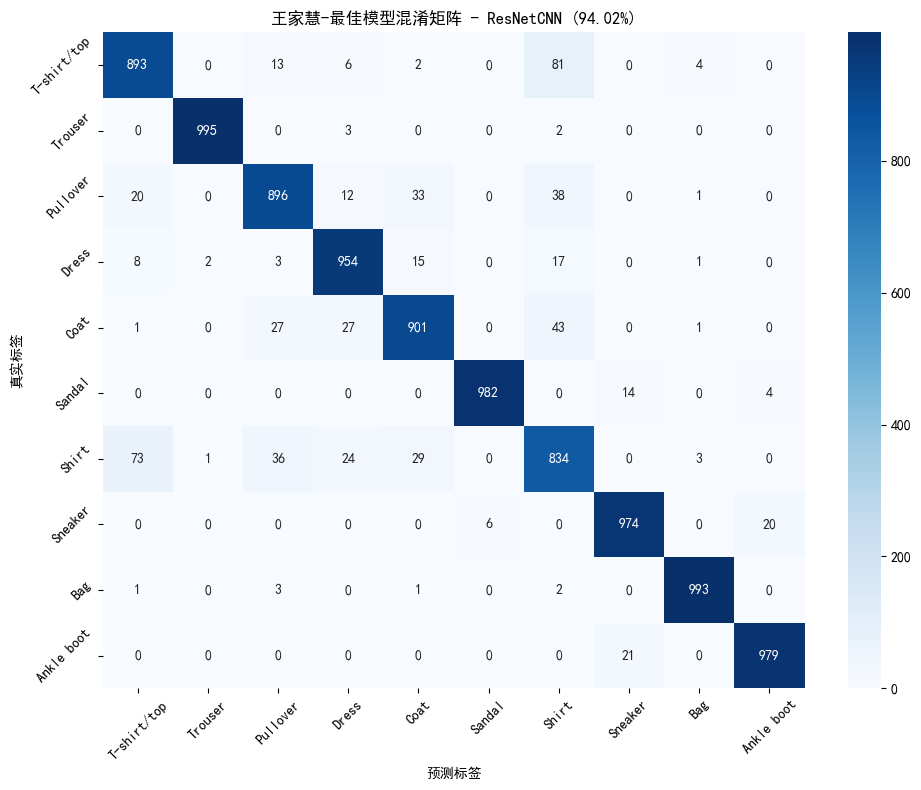

In [18]:
# ========== 10. 生成最佳模型的可视化 ==========
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    # 准确率对比柱状图
    plt.figure(figsize=(12, 6))
    models_names = [r['model_name'] for r in results]
    accuracies = [r['accuracy']*100 for r in results]
    train_times = [r['train_time'] for r in results]
    
    # 准确率对比
    plt.subplot(1, 2, 1)
    bars = plt.bar(models_names, accuracies, color='skyblue', edgecolor='navy')
    plt.ylim(85, 96)
    plt.ylabel('准确率 (%)')
    plt.title('王家慧-模型准确率对比')
    plt.xticks(rotation=45, ha='right')
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)
    
    # 训练时间对比
    plt.subplot(1, 2, 2)
    bars = plt.bar(models_names, train_times, color='lightcoral', edgecolor='navy')
    plt.ylabel('训练时间 (秒)')
    plt.title('王家慧-训练时间对比')
    plt.xticks(rotation=45, ha='right')
    for bar, time in zip(bars, train_times):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{time:.0f}s', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('model_comparison_charts.png', dpi=150, bbox_inches='tight')
    print(f"📈 对比图表已保存到: model_comparison_charts.png")
    
    # 最佳模型的混淆矩阵
    plt.figure(figsize=(10, 8))
    sns.heatmap(best_acc_model['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'王家慧-最佳模型混淆矩阵 - {best_acc_model["model_name"]} ({best_acc_model["accuracy"]*100:.2f}%)')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.savefig('best_model_confusion_matrix.png', dpi=150)
    print(f"最佳模型混淆矩阵已保存到: best_model_confusion_matrix.png")
    
except Exception as e:
    print(f"\n无法生成图表 (缺少matplotlib或seaborn): {e}")